Variational Autoencoders (VAEs)
======

The VAE implemented here uses the setup found in most VAE papers: a multivariate Normal distribution for the conditional distribution of the latent vectors given and input image ($q_{\phi}(z | x_i)$ in the slides) and a multivariate Bernoulli distribution for the conditional distribution of images given the latent vector ($p_{\theta}(x | z)$ in the slides). Using a Bernoulli distribution, the reconstruction loss (negative log likelihood of a data point in the output distribution) reduces to the pixel-wise binary cross-entropy. See the [original VAE paper](https://arxiv.org/pdf/1312.6114.pdf), Appendix C.1 for details.

In [3]:
%matplotlib inline
import os

import torch
import torch.nn as nn
import torch.nn.functional as F

MNIST Data Loading
-------------------

MNIST images show digits from 0-9 in 28x28 grayscale images. We do not center them at 0, because we will be using a binary cross-entropy loss that treats pixel values as probabilities in [0,1]. We create both a training set and a test set.

In [5]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

img_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = MNIST(root='./data/MNIST', download=True, train=True, transform=img_transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = MNIST(root='./data/MNIST', download=True, train=False, transform=img_transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [7]:
samples_per_label = {i: [] for i in range(10)}
SAMPLES_PER_LABEL_COUNT = 9

# Iterate through the dataset to collect the samples
# We iterate over the dataset directly (not the dataloader) for sequential access
for image, label in train_dataset:
    # Check if we still need samples for this label
    if len(samples_per_label[label]) < SAMPLES_PER_LABEL_COUNT:
        # Append the image (a PyTorch Tensor)
        samples_per_label[label].append(image)

    # Check if we have collected all 90 samples (9 per label * 10 labels)
    # This prevents unnecessary iteration over the entire dataset
    total_collected = sum(len(samples) for samples in samples_per_label.values())
    if total_collected == SAMPLES_PER_LABEL_COUNT * 10:
        break

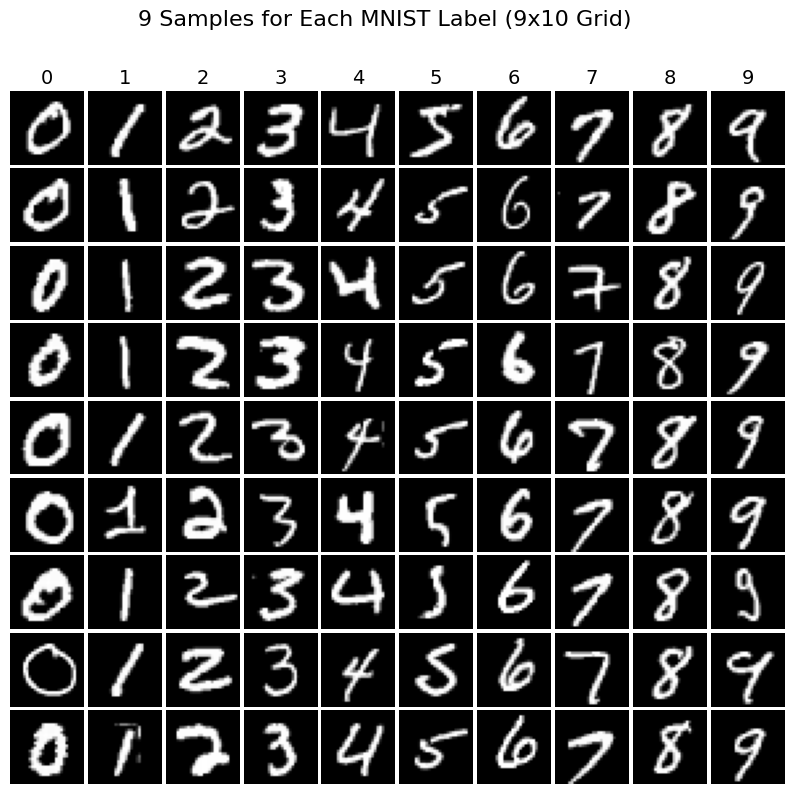

In [19]:
from matplotlib import pyplot as plt

N_ROWS = SAMPLES_PER_LABEL_COUNT # 9 rows for 9 samples of each digit
N_COLS = 10                       # 10 columns for the 10 digits (0-9)

# Create the figure and subplots
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS, N_ROWS))
plt.subplots_adjust(wspace=0.05, hspace=0.05) # Adjust spacing between plots

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Title the columns with the corresponding label (digit)
for col_idx in range(N_COLS):
    # Set the title for the first image of each column (the label/digit)
    axes[col_idx].set_title(str(col_idx), fontsize=14, pad=5)

# Iterate through the labels (columns)
for col_idx, label in enumerate(range(10)):
    # Iterate through the 9 samples (rows) for the current label
    for row_idx, image_tensor in enumerate(samples_per_label[label]):
        # Calculate the index in the flattened axes array:
        # index = row_idx * N_COLS + col_idx
        plot_index = row_idx * N_COLS + col_idx

        # Get the subplot axis
        ax = axes[plot_index]

        # Convert the PyTorch Tensor (1, 28, 28) to a NumPy array (28, 28)
        # and remove the channel dimension (squeeze)
        image_np = image_tensor.squeeze().cpu().numpy()

        # Display the image
        # 'cmap="gray"' is used for grayscale images like MNIST
        ax.imshow(image_np, cmap="gray")

        # Turn off axis ticks and labels for a cleaner grid view
        ax.axis('off')

# Display the final plot
plt.suptitle(f'{SAMPLES_PER_LABEL_COUNT} Samples for Each MNIST Label (9x10 Grid)', y=0.97, fontsize=16)
plt.show()

# Média das imagens

In [14]:
# --- 1. Setup ---
# Define the transformation: converts PIL image to PyTorch Tensor
img_transform = transforms.Compose([
    transforms.ToTensor()
])

# Load the training dataset. If the data isn't present, it will be downloaded.
train_dataset = MNIST(root='./data/MNIST', download=True, train=True, transform=img_transform)

# --- 2. Initialize containers for aggregation ---
num_labels = 10
# Get the shape of a single image tensor (1 channel, 28 height, 28 width)
image_shape = (1, 28, 28)

# Dictionary to accumulate the sum of images for each label.
# Initialized with a zero tensor of the correct shape.
sum_images = {i: torch.zeros(image_shape) for i in range(num_labels)}

# Dictionary to count the number of examples for each label.
counts = {i: 0 for i in range(num_labels)}

# --- 3. Iterate and Aggregate ---
print("Starting aggregation of images...")
for image, label in train_dataset:
    # Add the current image tensor to the running sum for its label
    sum_images[label] += image
    # Increment the count for that label
    counts[label] += 1
print("Aggregation complete.")

# --- 4. Calculate Mean ---
mean_images = {}
for label in range(num_labels):
    if counts[label] > 0:
        # Calculate the mean by dividing the sum of images by the count.
        mean_images[label] = sum_images[label] / counts[label]
    else:
        # Fallback for labels not present (unlikely in MNIST)
        mean_images[label] = torch.zeros(image_shape)
    
    # Optional: Print the count for verification
    print(f"Label {label}: {counts[label]} examples, Mean Calculated.")

Starting aggregation of images...
Aggregation complete.
Label 0: 5923 examples, Mean Calculated.
Label 1: 6742 examples, Mean Calculated.
Label 2: 5958 examples, Mean Calculated.
Label 3: 6131 examples, Mean Calculated.
Label 4: 5842 examples, Mean Calculated.
Label 5: 5421 examples, Mean Calculated.
Label 6: 5918 examples, Mean Calculated.
Label 7: 6265 examples, Mean Calculated.
Label 8: 5851 examples, Mean Calculated.
Label 9: 5949 examples, Mean Calculated.


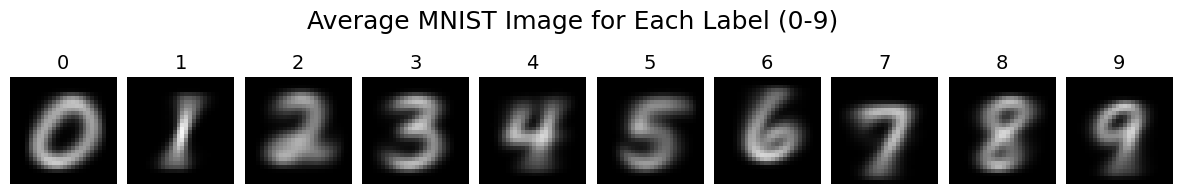

In [18]:
# --- 5. Plotting the Mean Images (1 row x 10 columns) ---
N_COLS = num_labels # 10 columns for labels 0-9
N_ROWS = 1

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 1.5, N_ROWS * 1.5))
plt.subplots_adjust(wspace=0.1, hspace=0.1) # Minimal spacing

for label in range(num_labels):
    ax = axes[label]

    # Convert the PyTorch Tensor (1, 28, 28) to a NumPy array (28, 28)
    image_tensor = mean_images[label]
    image_np = image_tensor.squeeze().cpu().numpy()

    # Display the image
    # Use vmin=0, vmax=1 to ensure consistent color scaling for the grayscale image
    ax.imshow(image_np, cmap="gray", vmin=0, vmax=1)

    # Set the title to the label (digit)
    ax.set_title(str(label), fontsize=14)

    # Turn off axis ticks and labels for a clean visual
    ax.axis('off')

# Set a main title for the figure
plt.suptitle('Average MNIST Image for Each Label (0-9)', y=1.3, fontsize=18)

# Show the figure
plt.show()